In [22]:
#importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
#Loading the dataset
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [24]:
#Exploring the dataset
print(df.shape)
print(df.info())
print(df.describe())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.

In [25]:
#Selecting Features and Targets
X = df[['bmi']]
y = df['charges']

In [26]:
#Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
#Training The Model & predicting
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [28]:
#Displaying between Actual & Predicted Values
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

print(comparison.head(10))

   Actual Charges  Predicted Charges
0      9095.06825       11232.663072
1      5272.17580       13134.018128
2     29330.98315       11903.729562
3      9301.89355       11456.351902
4     33750.29180       13879.647562
5      4536.25900       18188.600817
6      2117.33885       10188.781864
7     14210.53595       16228.380279
8      3732.62510        8138.300921
9     10264.44210       12612.077524


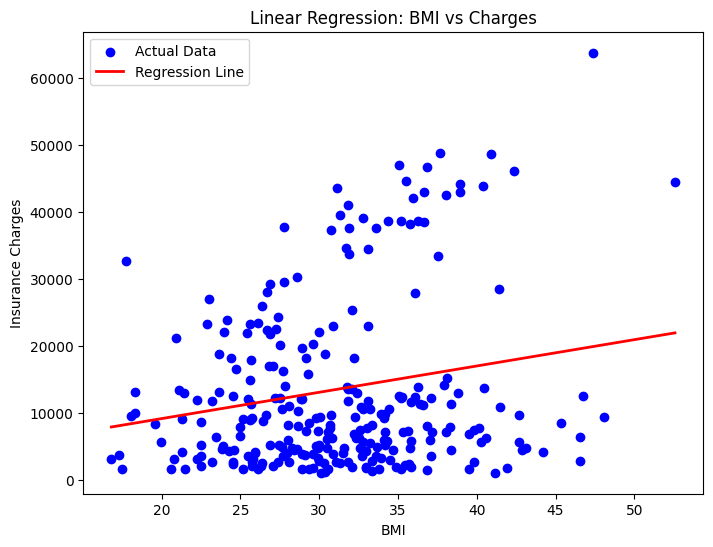

In [29]:
#Plotting Regression Line
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')

sorted_index = X_test['bmi'].argsort()
X_sorted = X_test.iloc[sorted_index]
y_pred_sorted = model.predict(X_sorted)

plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Regression Line')

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Linear Regression: BMI vs Charges")
plt.legend()

plt.show()

In [30]:
#Printing Slope,Intercept & Eqns
slope = model.coef_[0]
intercept = model.intercept_

print("Slope (m):", slope)
print("Intercept (c):", intercept)

print(f"\nEquation:\nCharges = {slope:.2f} × BMI + {intercept:.2f}")

Slope (m): 392.43654416987977
Intercept (c): 1353.0730722046683

Equation:
Charges = 392.44 × BMI + 1353.07


In [31]:
#Evaluation (MSE,MAE,r2)
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R² Score :", r2)

MAE : 9784.65259627133
MSE : 149085057.03839505
R² Score : 0.03970193117941878


In [32]:
#Prediction for New Values
new_bmi = pd.DataFrame({
    "bmi":[22,28,35]
})

predictions = model.predict(new_bmi)

result = pd.DataFrame({
    "BMI":new_bmi["bmi"],
    "Predicted Charges":predictions
})

print(result)

   BMI  Predicted Charges
0   22        9986.677044
1   28       12341.296309
2   35       15088.352118


In [33]:
#Comparing Model Performance
print("\nModel Evaluation")

print("MAE :", mae)
print("MSE :", mse)
print("R² :", r2)

if r2 >= 0.80:
    print("\nPerformance : BEST")
    print("Reason : The model explains most of the variation in the data.")
elif r2 >= 0.60:
    print("\nPerformance : GOOD")
    print("Reason : The model predicts reasonably well but can still be improved.")
else:
    print("\nPerformance : NEEDS IMPROVEMENT")
    print("Reason : The model explains only a small portion of the variation.")


Model Evaluation
MAE : 9784.65259627133
MSE : 149085057.03839505
R² : 0.03970193117941878

Performance : NEEDS IMPROVEMENT
Reason : The model explains only a small portion of the variation.
